In [1]:
%%capture
# %%capture prevents this cell from printing a ton of STDERR stuff to the screen

%pip install seaborn
%pip install torch

In [2]:
import torch ## torch let's us create tensors and also provides helper functions
import torch.nn as nn ## torch.nn gives us nn.Module(), nn.Embedding() and nn.Linear()
import torch.nn.functional as F # This gives us relu()

import matplotlib.pyplot as plt ## matplotlib allows us to draw graphs.
import seaborn as sns ## seaborn makes it easier to draw nice-looking graphs.

In [3]:
class myNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.w1 = torch.tensor(1.43)
        self.b1 = torch.tensor(-0.61)

        self.w2 = torch.tensor(2.63)
        self.b2 = torch.tensor(-0.27)

        self.w3 = torch.tensor(-3.89)
        self.w4 = torch.tensor(1.35)


    def forward(self, input_values):
        top_x_axis_values = (input_values * self.w1) + self.b1
        bottom_x_axis_values = (input_values * self.w2) + self.b2

        top_y_axis_values = F.relu(top_x_axis_values)
        bottom_y_axis_values = F.relu(bottom_x_axis_values)

        output_values = (top_y_axis_values * self.w3) + (bottom_y_axis_values * self.w4)

        return output_values

In [11]:
model = myNN()
input_doses = torch.linspace(start=0, end=1, steps=11)

Text(0.5, 0, 'Dose')

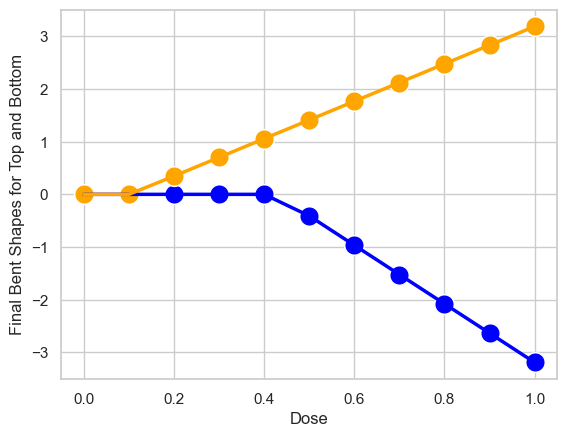

In [16]:
sns.set(style="whitegrid")

top_y_axis_values = F.relu((model.w1 * input_doses) + model.b1)
bottom_y_axis_values = F.relu((model.w2 * input_doses) + model.b2)
final_top_y_axis_values = top_y_axis_values * model.w3
final_bottom_y_axis_values = bottom_y_axis_values * model.w4

sns.scatterplot(x=input_doses,
                y=final_top_y_axis_values,
                color='blue',
                s=200)

sns.lineplot(x=input_doses,
             y=final_top_y_axis_values,
             color='blue',
             linewidth=2.5)

sns.scatterplot(x=input_doses,
                y=final_bottom_y_axis_values,
                color='orange',
                s=200)

sns.lineplot(x=input_doses,
             y=final_bottom_y_axis_values,
             color='orange',
             linewidth=2.5)

plt.ylabel('Final Bent Shapes for Top and Bottom')
plt.xlabel('Dose')

Text(0.5, 0, 'Dose')

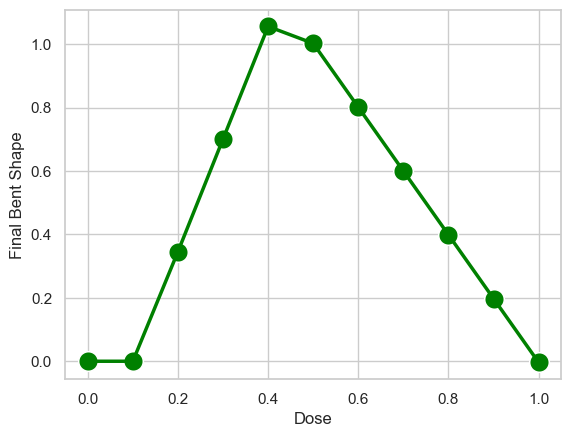

In [17]:
sns.set(style="whitegrid")

final_bent_shape = final_top_y_axis_values + final_bottom_y_axis_values

sns.scatterplot(x=input_doses,
                y=final_bent_shape,
                color='green',
                s=200)

sns.lineplot(x=input_doses,
             y=final_bent_shape,
             color='green',
             linewidth=2.5)

plt.ylabel('Final Bent Shape')
plt.xlabel('Dose')